
Processing PD Astrocyte: pd_astro_1_40_55.npy (ID: 1)
  Using Precomputed Scale Factor: 0.030
Saved Rescaled PD Astrocyte to: Step_6_Rescaled_PD_NPYs/pd_astro_1_40_55_rescaled.npy


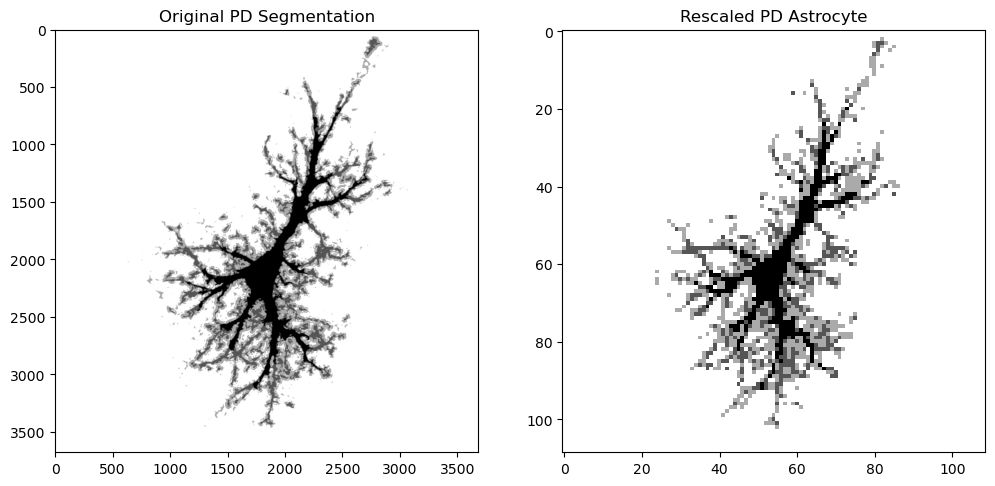

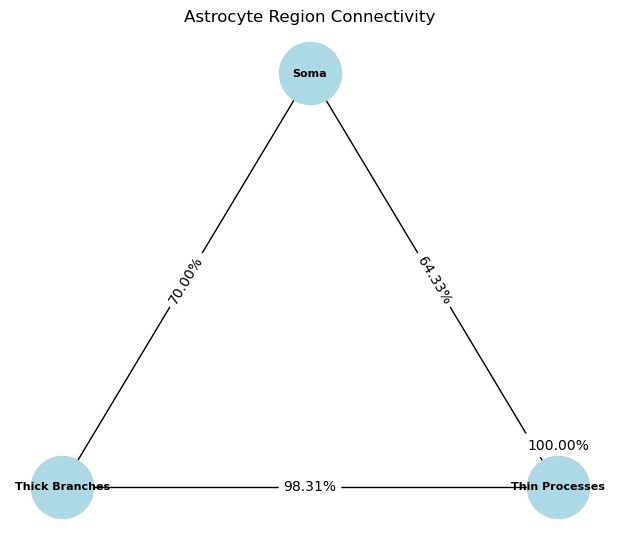


Processing PD Astrocyte: pd_astro_1_60_70.npy (ID: 1)
  Using Precomputed Scale Factor: 0.030
Saved Rescaled PD Astrocyte to: Step_6_Rescaled_PD_NPYs/pd_astro_1_60_70_rescaled.npy


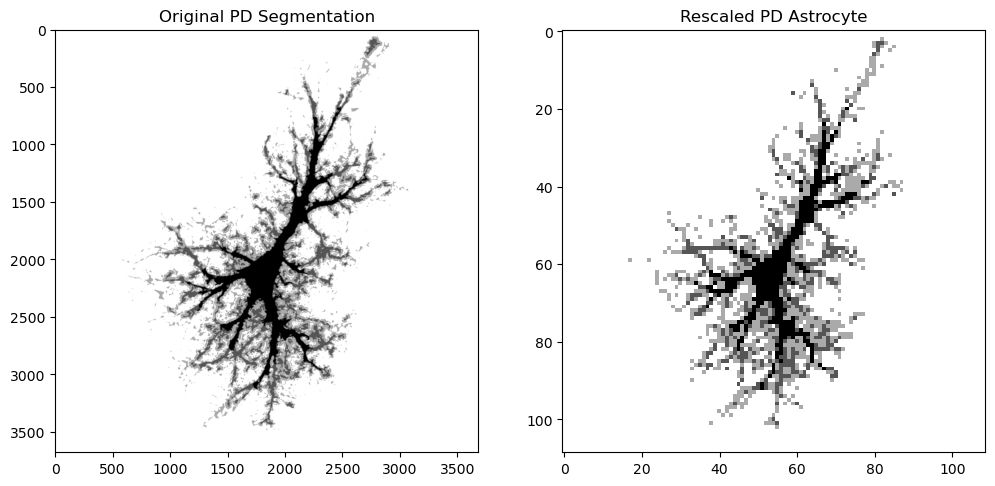

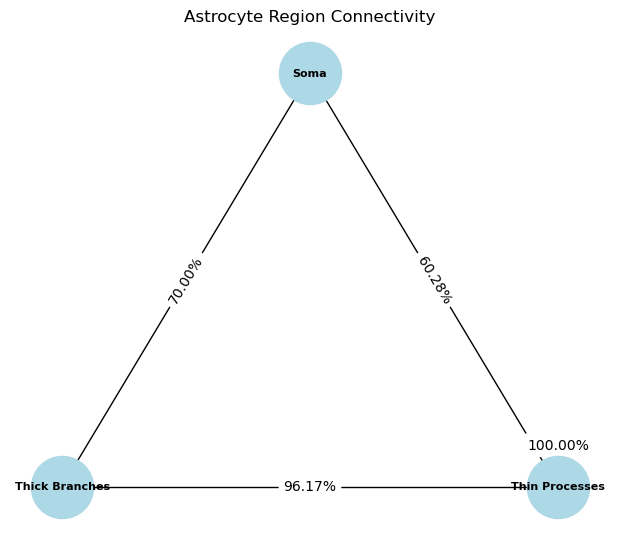


Processing PD Astrocyte: pd_astro_1_80_85.npy (ID: 1)
  Using Precomputed Scale Factor: 0.030
Saved Rescaled PD Astrocyte to: Step_6_Rescaled_PD_NPYs/pd_astro_1_80_85_rescaled.npy


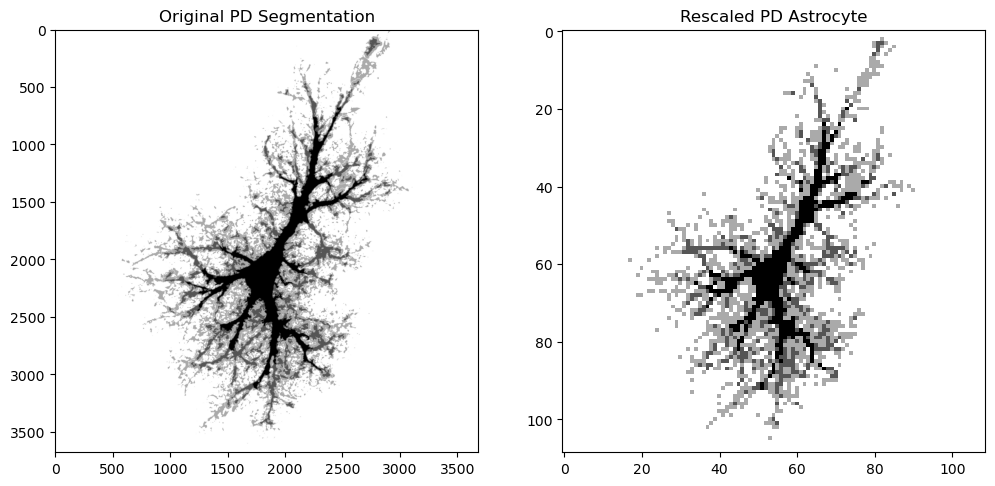

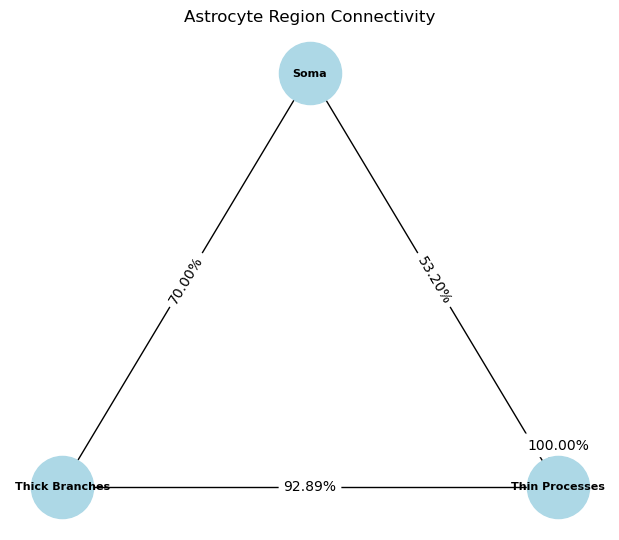

In [3]:
import numpy as np
import os
import json
import re
import matplotlib.pyplot as plt
from skimage.transform import rescale
import networkx as nx


def visualize_connectivity_graph(connectivity_pixel):
    """
    Visualizes the updated connectivity graph for astrocyte regions.
    
    Parameters:
        connectivity_pixel (dict): A dictionary containing connectivity percentages between regions.
    """
    # Define the graph
    connectivity_graph_pixel = nx.Graph()
    
    # Add nodes (Soma, Thick Branches, Thin Processes)
    connectivity_graph_pixel.add_nodes_from(["Soma", "Thick Branches", "Thin Processes"])
    
    # Define the connectivity edges and weights
    connectivity_edges_pixel = {
        ("Soma", "Thick Branches"): connectivity_pixel["Soma ↔ Thick"],
        ("Soma", "Thin Processes"): connectivity_pixel["Soma ↔ Thin"],
        ("Thick Branches", "Thin Processes"): connectivity_pixel["Thick ↔ Thin"],
        ("Thin Processes", "Thin Processes"): connectivity_pixel["Thin ↔ Thin"],
    }
    
    # Add edges with weights (percentages)
    for edge, weight in connectivity_edges_pixel.items():
        connectivity_graph_pixel.add_edge(edge[0], edge[1], weight=weight)
    
    # Define a fixed triangular layout
    pos = {
        "Soma": (0, 1),
        "Thick Branches": (-1, 0),
        "Thin Processes": (1, 0),
    }
    
    # Extract edge weights for labeling
    weights = nx.get_edge_attributes(connectivity_graph_pixel, "weight")
    
    # Visualize the triangular graph
    plt.figure(figsize=(6, 5))
    
    # Draw the graph with nodes
    nx.draw(
        connectivity_graph_pixel,
        pos,
        with_labels=True,
        node_size=2000,
        node_color="lightblue",
        font_size=8,
        font_weight="bold",
    )
    
    # Draw edges with connectivity labels
    nx.draw_networkx_edge_labels(
        connectivity_graph_pixel,
        pos,
        edge_labels={k: f"{v:.2f}%" for k, v in weights.items()},
        font_size=10,
    )
    
    plt.title("Astrocyte Region Connectivity")
    plt.show()

def compute_pixel_connectivity(mask1, mask2):
            connected_pixels = 0
            total_pixels = np.sum(mask1)
            height, width = mask1.shape  
            radius = 3  

            for i in range(height): 
                for j in range(width):  
                    if mask1[i, j]:  
                        i_min = max(0, i - radius)
                        i_max = min(height, i + radius + 1)
                        j_min = max(0, j - radius)
                        j_max = min(width, j + radius + 1)

                        neighbors = mask2[i_min:i_max, j_min:j_max].ravel()
                        if np.any(neighbors): 
                            connected_pixels += 1

            return (connected_pixels / total_pixels) * 100 if total_pixels > 0 else 0
        
        
# ==========================================
# Set Directories
# ==========================================
input_dir_pd = "Step_5_Cropped_PD_NPYs"  # PD astrocytes before processing
output_dir_pd = "Step_6_Rescaled_PD_NPYs"  # Directory for rescaled PD astrocytes
scaling_factors_file = "scaling_factors.json"  # File containing scale factors from healthy astrocytes
os.makedirs(output_dir_pd, exist_ok=True)

# ==========================================
# Load Scaling Factors
# ==========================================
with open(scaling_factors_file, "r") as f:
    scaling_factors = json.load(f)

# ==========================================
# Function to Extract Astrocyte ID
# ==========================================
def extract_astro_id(pd_filename):
    """Extracts the numeric ID from the PD filename to match with healthy scaling factors."""
    match = re.search(r"pd_astro_(\d+)", pd_filename)  # Extract the numeric ID
    if match:
        return match.group(1)  # Return the astrocyte ID (e.g., "1")
    return None

# ==========================================
# Loop Through Each PD Astrocyte
# ==========================================
for filename in sorted(os.listdir(input_dir_pd)):
    if filename.endswith(".npy"):
        pd_file_path = os.path.join(input_dir_pd, filename)

        # Extract astrocyte ID
        astrocyte_id = extract_astro_id(filename)

        if not astrocyte_id or astrocyte_id not in scaling_factors:
            print(f"⚠️ Skipping {filename} (No matching scaling factor found for ID {astrocyte_id})")
            continue

        # Get the precomputed scale factor
        scale_factor = scaling_factors[astrocyte_id]

        print(f"\nProcessing PD Astrocyte: {filename} (ID: {astrocyte_id})")
        print(f"  Using Precomputed Scale Factor: {scale_factor:.3f}")

        # Load the PD astrocyte data
        pd_data = np.load(pd_file_path)

        # ==========================================
        # Ensure Fixed Label Assignments
        # ==========================================
        soma_label = 0
        thick_branch_label = 1
        thin_process_label = 2
        background_label = 3

        # Create masks using fixed labels
        soma_mask = pd_data == soma_label
        thick_branch_mask = pd_data == thick_branch_label
        thin_process_mask = pd_data == thin_process_label
        background_mask = pd_data == background_label
        
        # Compute current soma size
        current_soma_pixels = np.sum(soma_mask)

        # ========================================================================
        # Rescale the PD Astrocyte Using the Healthy Scale Factor
        # ========================================================================
        rescaled_pd = rescale(
            pd_data, scale_factor, anti_aliasing=False, order=0, preserve_range=True
        ).astype(np.uint8)

        # ==========================================
        # Save Rescaled PD Astrocyte
        # ==========================================
        output_path = os.path.join(output_dir_pd, filename.replace(".npy", "_rescaled.npy"))
        np.save(output_path, rescaled_pd)

        print(f"Saved Rescaled PD Astrocyte to: {output_path}")

        # ==========================================
        # Compute New Pixel Counts
        # ==========================================
        soma_mask_rescaled = rescaled_pd == soma_label
        thick_branch_mask_rescaled = rescaled_pd == thick_branch_label
        thin_process_mask_rescaled = rescaled_pd == thin_process_label
        background_mask_rescaled = rescaled_pd == background_label

        soma_pixels_rescaled = np.sum(soma_mask_rescaled)
        thick_pixels_rescaled = np.sum(thick_branch_mask_rescaled)
        thin_pixels_rescaled = np.sum(thin_process_mask_rescaled)
        background_pixels_rescaled = np.sum(background_mask_rescaled)

        # ==========================================
        # Visualization
        # ==========================================
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(pd_data, cmap="gray")
        axs[0].set_title("Original PD Segmentation")
        axs[1].imshow(rescaled_pd, cmap="gray")
        axs[1].set_title("Rescaled PD Astrocyte")
        plt.show()

        # =======================================================================================
        # Compute Pixel-Level Connectivity (Including Self-Connectivity): inter_region_connection
        # =======================================================================================

        connectivity_pixel = {
            "Soma ↔ Thick": compute_pixel_connectivity(thick_branch_mask_rescaled, soma_mask_rescaled),
            "Thick ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, thick_branch_mask_rescaled),
            "Soma ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, soma_mask_rescaled),
            "Thin ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, thin_process_mask_rescaled),
            "Soma ↔ Soma": compute_pixel_connectivity(soma_mask_rescaled, soma_mask_rescaled),
            "Thick ↔ Thick": compute_pixel_connectivity(thick_branch_mask_rescaled, thick_branch_mask_rescaled),
            "Thin ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, thin_process_mask_rescaled),
        }
        visualize_connectivity_graph(connectivity_pixel)
